# DDLs_10 — parsing & column lineage smoke test

Loads the **first statement** from `data/DDLs_10.txt` and exercises:

1. **sqlglot (deterministic)** — parse, column lineage, simplify, chunk split
2. **LLM enrichment** — `SQL2GraphPipeline` structured extraction
3. **Graph drawing** — deterministic column graph + full pipeline column-lineage graph

Put `HF_TOKEN` in the repo-root `.env` file (loaded via `load_dotenv` in the setup cell) for the LLM + full-graph sections.

In [1]:
from __future__ import annotations

import json
import os
import re
from pathlib import Path

import networkx as nx
import pandas as pd
from IPython.display import Markdown, display

from dotenv import load_dotenv

from Classes import (
    ColumnLineageExtractor,
    Config,
    PipelineOrchestrator,
    SQL2GraphParser,
    SQL2GraphVisualizer,
    SQLLogicalChunkParser,
    SQLParser,
    setup_logging,
)
from Classes.graph_drawer import JsonLineageDrawer
from Classes.pipeline.llm_helpers import resolve_hf_token

setup_logging("INFO")

ROOT = Path.cwd()
if not (ROOT / "data" / "DDLs_10.txt").exists() and (ROOT.parent / "data" / "DDLs_10.txt").exists():
    ROOT = ROOT.parent

# Load repo .env into os.environ (Jupyter does not do this automatically).
for env_path in (ROOT / ".env", ROOT.parent / ".env"):
    if env_path.exists():
        load_dotenv(env_path)
        break

DDL_FILE = ROOT / "data" / "DDLs_10.txt"
DIALECT = "spark"  # postgres/hive also work for this file
print("repo root:", ROOT)
print("DDL file exists:", DDL_FILE.exists())
print("HF_TOKEN loaded:", bool(resolve_hf_token()))

/Users/nikolajabramov/PycharmProjects/llm4lineage/.venv/lib/python3.14/site-packages/langchain_core/_api/deprecation.py:27: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


repo root: /Users/nikolajabramov/PycharmProjects/llm4lineage
DDL file exists: True
HF_TOKEN loaded: True


## 1. Load the first statement

In [2]:
def load_statements(path: Path) -> list[str]:
  """Split DDLs_10.txt into individual INSERT statements."""
  raw = path.read_text(encoding="utf-8")
  parts = re.split(r"(?=INSERT\s+INTO\s+)", raw.strip(), flags=re.IGNORECASE)
  return [part.strip().rstrip(";") for part in parts if part.strip()]


statements = load_statements(DDL_FILE)
SQL = statements[0]

print(f"total statements in file: {len(statements)}")
print(f"first statement length: {len(SQL)} chars")
print("target table prefix:", SQL[:80], "...")

total statements in file: 10
first statement length: 3447 chars
target table prefix: INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_collat_dmcl_attr  WITH pprb_attr_v ...


In [3]:
display(Markdown(f"```sql\n{SQL[:1500]}\n...\n```"))

```sql
INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_collat_dmcl_attr  WITH pprb_attr_val AS (
         SELECT a_agr_collat_mkt_period.host_eks_id AS host_agr_collat_id,
            a_agr_collat_mkt_period.start_dt,
            a_agr_collat_mkt_period.end_dt,
            'mkt_price_amt'::text AS attr_name,
            a_agr_collat_mkt_period.mkt_price_amt AS attr_val_numeric,
            NULL::uuid AS attr_val_uuid,
            NULL::bigint AS attr_val_bigint
           FROM s_grnplm_vd_t_bvd_db_dmcl.a_agr_collat_mkt_period
          WHERE (a_agr_collat_mkt_period.mkt_price_amt IS NOT NULL)
        UNION ALL
         SELECT a_agr_collat_mkt_period.host_eks_id AS host_agr_collat_id,
            a_agr_collat_mkt_period.start_dt,
            a_agr_collat_mkt_period.end_dt,
            'mkt_price_rub'::text AS attr_name,
            a_agr_collat_mkt_period.mkt_price_rub AS attr_val_numeric,
            NULL::uuid AS attr_val_uuid,
            NULL::bigint AS attr_val_bigint
           FROM s_grnplm_vd_t_bvd_db_dmcl.a_agr_collat_mkt_period
          WHERE (a_agr_collat_mkt_period.mkt_price_rub IS NOT NULL)
        UNION ALL
         SELECT mkt_prd.host_eks_id AS host_agr_collat_id,
            mkt_prd.start_dt,
            mkt_prd.end_dt,
            'mkt_crncy_id'::text AS attr_name,
            NULL::numeric AS attr_val_numeric,
            NULL::uuid AS attr_val_uuid,
            v_crncy.crncy_id AS attr_val_bigint
           FROM (((s_grnplm_vd_t_bvd_db_dmcl.a_agr_collat_mkt_period m
...
```

## 2. Parse + column lineage (deterministic)

In [4]:
parser = SQLParser(dialect=DIALECT, error_on_incomplete=False)
ast = parser.parse(SQL)
print("AST root:", type(ast).__name__)

lineage_extractor = ColumnLineageExtractor(dialect=DIALECT)
column_lineage = lineage_extractor.extract(ast)
print("output columns:", len(column_lineage))

rows = []
for entry in column_lineage:
    sources = [
        f"{ref.get('table') or '?'}" + "." + ref["column"]
        for ref in entry["source_columns"]
    ]
    rows.append(
        {
            "target_column": entry["target_column"],
            "source_columns": ", ".join(sources) if sources else "(none)",
            "expression": entry["expression"][:120],
        }
    )

display(pd.DataFrame(rows))

AST root: Insert
output columns: 8


,target_column,source_columns,expression
0,agr_collat_id,t2.agr_collat_id,t2.agr_collat_id AS agr_collat_id
1,host_agr_collat_id,"a_agr_collat_mkt_period.host_eks_id, mkt_prd.h...",t1.host_agr_collat_id AS host_agr_collat_id
2,start_dt,"a_agr_collat_mkt_period.start_dt, mkt_prd.star...",t1.start_dt AS start_dt
3,end_dt,"a_agr_collat_mkt_period.end_dt, mkt_prd.end_dt...",t1.end_dt AS end_dt
4,attr_name,?.3,t1.attr_name AS attr_name
5,attr_val_numeric,"a_agr_collat_mkt_period.mkt_price_amt, a_agr_c...",t1.attr_val_numeric AS attr_val_numeric
6,attr_val_uuid,"?.5, a.agr_collat_qlty_cat_type_id, a.asset_co...",t1.attr_val_uuid AS attr_val_uuid
7,attr_val_uuid2bigint,"?.6, v_crncy.crncy_id, ?.5, a.agr_collat_qlty_...","COALESCE(t1.attr_val_bigint, CAST((ABS(UUID_HA..."


In [5]:
config = Config(llm_provider="mock", sql_dialect=DIALECT)
orchestrator = PipelineOrchestrator(config)
pipeline_result = orchestrator.run(SQL, instruction="Summarize target column dependencies.")

print("pipeline success:", pipeline_result.success)
print("model:", pipeline_result.model_used)
print("latency (s):", pipeline_result.latency_seconds)
if pipeline_result.error:
    print("error:", pipeline_result.error)

2026-07-28 19:51:33 | INFO     | Classes.pipeline.core.llm_factory | Creating LLM instance for provider: mock
2026-07-28 19:51:33 | INFO     | Classes.pipeline.core.orchestrator | Pipeline completed in 0.003s for query: INSERT INTO s_grnplm_vd_t_bvd_db_dmslcl.d_agr_collat_dmcl_at…


pipeline success: True
model: GenericFakeChatModel
latency (s): 0.003


## 3. SQL2Graph simplify (deterministic parser payload)

In [6]:
s2g_parser = SQL2GraphParser()
simplified = s2g_parser.simplify(SQL, dialect=DIALECT)

print("parser_used:", simplified.get("parser_used"))
print("statement_type:", simplified.get("statement_type"))
print("target_table:", simplified.get("target_table"))
print("ctes:", [c.get("alias") for c in simplified.get("ctes", [])])
print("from:", simplified.get("from"))
print("subgraph_blocks:", len(simplified.get("subgraph_blocks", [])))
print("embedded column_lineage rows:", len(simplified.get("column_lineage", [])))

parser_used: True
statement_type: insert
target_table: d_agr_collat_dmcl_attr
ctes: ['pprb_attr_val']
from: [{'table': 'pprb_attr_val', 'alias': 't1'}, {'table': 'd_agr_collat', 'alias': 't2'}]
subgraph_blocks: 9
embedded column_lineage rows: 8


## 4. Logical chunk split

In [7]:
chunk_parser = SQLLogicalChunkParser()
chunks = chunk_parser.preparse(SQL, dialect=DIALECT)

chunk_df = pd.DataFrame(
    [
        {
            "id": c["id"],
            "type": c["chunk_type"],
            "sql_preview": (c.get("sql") or "")[:100] + "...",
        }
        for c in chunks["chunks"]
    ]
)
display(chunk_df)
print("links:", chunks["links"])
print("warnings:", chunks.get("warnings"))

,id,type,sql_preview
0,pprb_attr_val,cte,SELECT a_agr_collat_mkt_period.host_eks_id AS ...
1,d_agr_collat_dmcl_attr,target,d_agr_collat_dmcl_attr...
2,main,query,"SELECT t2.agr_collat_id, t1.host_agr_collat_id..."


links: [{'source': 'main', 'target': 'd_agr_collat_dmcl_attr', 'link_type': 'INSERT', 'condition': ''}]
warnings: ["Disconnected chunks: ['d_agr_collat_dmcl_attr', 'main']"]


## 5. Build column lineage graph (deterministic, no LLM)

In [8]:
def build_column_lineage_graph(column_lineage: list[dict], target_table: str | None = None) -> nx.DiGraph:
    """Build a simple source-column -> target-column graph from sqlglot lineage records."""
    prefix = target_table or "output"
    graph = nx.DiGraph()
    for entry in column_lineage:
        target_id = f"{prefix}.{entry['target_column']}"
        graph.add_node(target_id, node_type="output_column")
        for ref in entry.get("source_columns") or []:
            alias = ref.get("table") or "unknown"
            source_id = f"{alias}.{ref['column']}"
            graph.add_node(source_id, node_type="source_column")
            graph.add_edge(source_id, target_id, edge_type="DERIVED_FROM")
    return graph


lineage_graph = build_column_lineage_graph(
    column_lineage,
    target_table=simplified.get("target_table"),
)

print("nodes:", lineage_graph.number_of_nodes())
print("edges:", lineage_graph.number_of_edges())
print("sample edges:")
for src, dst, data in list(lineage_graph.edges(data=True))[:12]:
    print(f"  {src} --{data.get('edge_type')}--> {dst}")

nodes: 27
edges: 22
sample edges:
  t2.agr_collat_id --DERIVED_FROM--> d_agr_collat_dmcl_attr.agr_collat_id
  a_agr_collat_mkt_period.host_eks_id --DERIVED_FROM--> d_agr_collat_dmcl_attr.host_agr_collat_id
  mkt_prd.host_eks_id --DERIVED_FROM--> d_agr_collat_dmcl_attr.host_agr_collat_id
  t.host_eks_agr_collat_id --DERIVED_FROM--> d_agr_collat_dmcl_attr.host_agr_collat_id
  a_agr_collat_mkt_period.start_dt --DERIVED_FROM--> d_agr_collat_dmcl_attr.start_dt
  mkt_prd.start_dt --DERIVED_FROM--> d_agr_collat_dmcl_attr.start_dt
  a.start_dt --DERIVED_FROM--> d_agr_collat_dmcl_attr.start_dt
  a_agr_collat_mkt_period.end_dt --DERIVED_FROM--> d_agr_collat_dmcl_attr.end_dt
  mkt_prd.end_dt --DERIVED_FROM--> d_agr_collat_dmcl_attr.end_dt
  a.end_dt --DERIVED_FROM--> d_agr_collat_dmcl_attr.end_dt
  unknown.3 --DERIVED_FROM--> d_agr_collat_dmcl_attr.attr_name
  a_agr_collat_mkt_period.mkt_price_amt --DERIVED_FROM--> d_agr_collat_dmcl_attr.attr_val_numeric


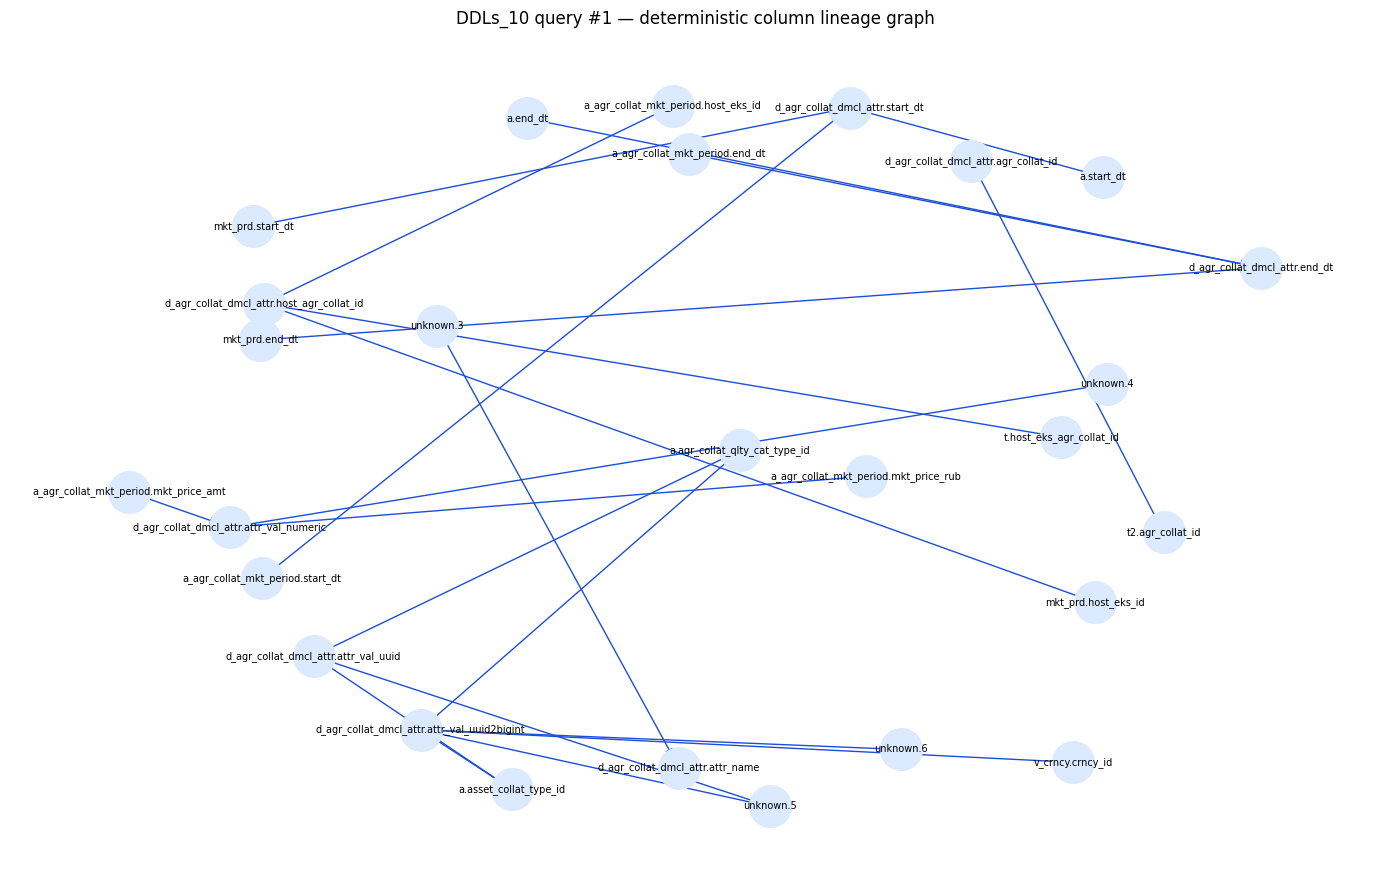

In [9]:
try:
    import matplotlib.pyplot as plt

    pos = nx.spring_layout(lineage_graph, seed=0, k=1.4)
    plt.figure(figsize=(14, 9))
    nx.draw_networkx_nodes(lineage_graph, pos, node_size=900, node_color="#dbeafe")
    nx.draw_networkx_labels(lineage_graph, pos, font_size=7)
    nx.draw_networkx_edges(lineage_graph, pos, edge_color="#1d4ed8", arrows=True, arrowsize=12)
    plt.title("DDLs_10 query #1 — deterministic column lineage graph")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
except Exception as exc:
    print("matplotlib plot skipped:", exc)

## 6. Full pipeline: sqlglot → LLM verify → enhance

**Step 1** — `SQL2GraphParser.simplify()` + `build_deterministic_extraction()` (sqlglot only)

**Step 2** — `SQL2GraphLLMExtractor.verify_and_enhance()` checks the draft against the SQL

**Step 3** — LLM returns corrected JSON only where sqlglot under-specified; graph is built from the result

Requires `HF_TOKEN` in `.env` for steps 2–3. Set `use_llm=False` to stop after step 1.

In [10]:
graph_result = None
deterministic_extraction = None

# Step 1: sqlglot-only draft (always runs)
s2g_parser = SQL2GraphParser()
simplified_for_pipeline = s2g_parser.simplify(SQL, dialect=DIALECT)
deterministic_extraction = s2g_parser.build_deterministic_extraction(
    simplified_for_pipeline,
    dialect=DIALECT,
)
print("pipeline step 1 (sqlglot) output columns:", len(deterministic_extraction["output_columns"]))
print("pipeline step 1 CTEs:", [cte.get("alias") for cte in deterministic_extraction.get("ctes", [])])

hf_token = resolve_hf_token()
if not hf_token:
    print("HF_TOKEN not set — skipping LLM verify/enhance (step 2–3).")
else:
    from Classes import SQL2GraphLLMExtractor, SQL2GraphPipeline

    llm = SQL2GraphLLMExtractor(hf_token=hf_token)
    pipeline = SQL2GraphPipeline(llm_extractor=llm, parser=s2g_parser)
    graph_result = pipeline.run(SQL, dialect=DIALECT, include_visualization=True)

    if "error" in graph_result:
        print("SQL2Graph error:", graph_result["error"])
        if graph_result.get("details"):
            print(graph_result["details"])
        graph_result = None
    else:
        print("pipeline stage:", graph_result.get("pipeline_stage"))
        print("graph nodes:", len(graph_result["graph"]["nodes"]))
        print("graph links:", len(graph_result["graph"]["links"]))
        print("validation warnings:", graph_result.get("warnings", []))
        print("is_dag:", graph_result["metadata"].get("is_dag"))

2026-07-28 19:51:34 | INFO     | Classes.pipeline.core.llm_factory | Creating LLM instance for provider: huggingface_inference


pipeline step 1 (sqlglot) output columns: 8
pipeline step 1 CTEs: ['pprb_attr_val']
pipeline stage: llm_verified
graph nodes: 53
graph links: 89
validation warnings: []
is_dag: True


## 7. Draw graphs (sqlglot draft vs full pipeline)

Compare:
1. **Chunk graph** — sqlglot logical split
2. **Deterministic column lineage** — step 1 draft only
3. **Full pipeline graph** — after LLM verify/enhance (step 2–3)

LINEAGE JSON SUMMARY
Nodes: 3
Links: 1
Node types: {'chunk': 3}
Chunk types: cte, query, target
Link types: INSERT
Sample node ids: ['pprb_attr_val', 'd_agr_collat_dmcl_attr', 'main']


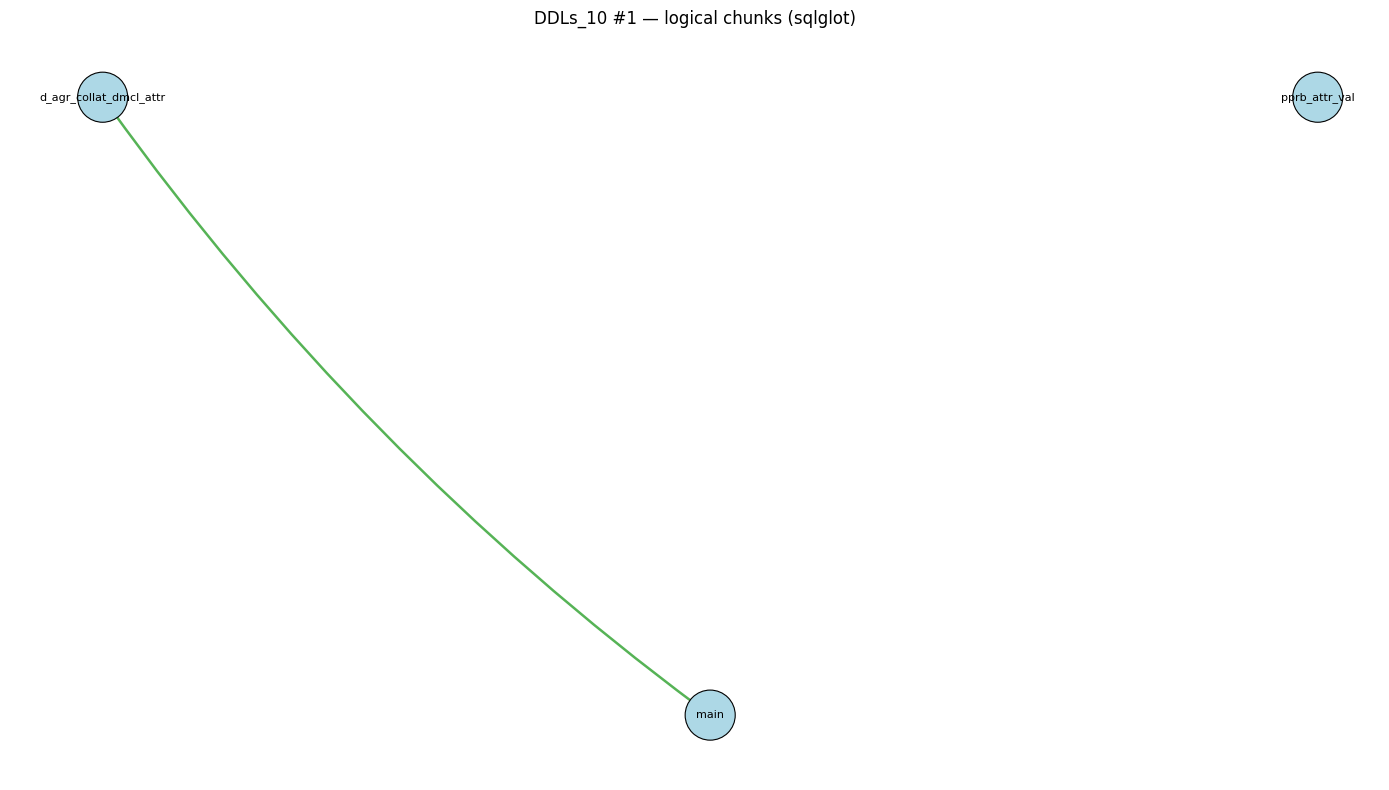

In [11]:
# 7a. Chunk graph (sqlglot deterministic)
chunk_drawer = JsonLineageDrawer(chunks)
chunk_drawer.print_summary()
chunk_drawer.show_static(
    title="DDLs_10 #1 — logical chunks (sqlglot)",
    layout="hierarchical",
    figsize=(14, 8),
)

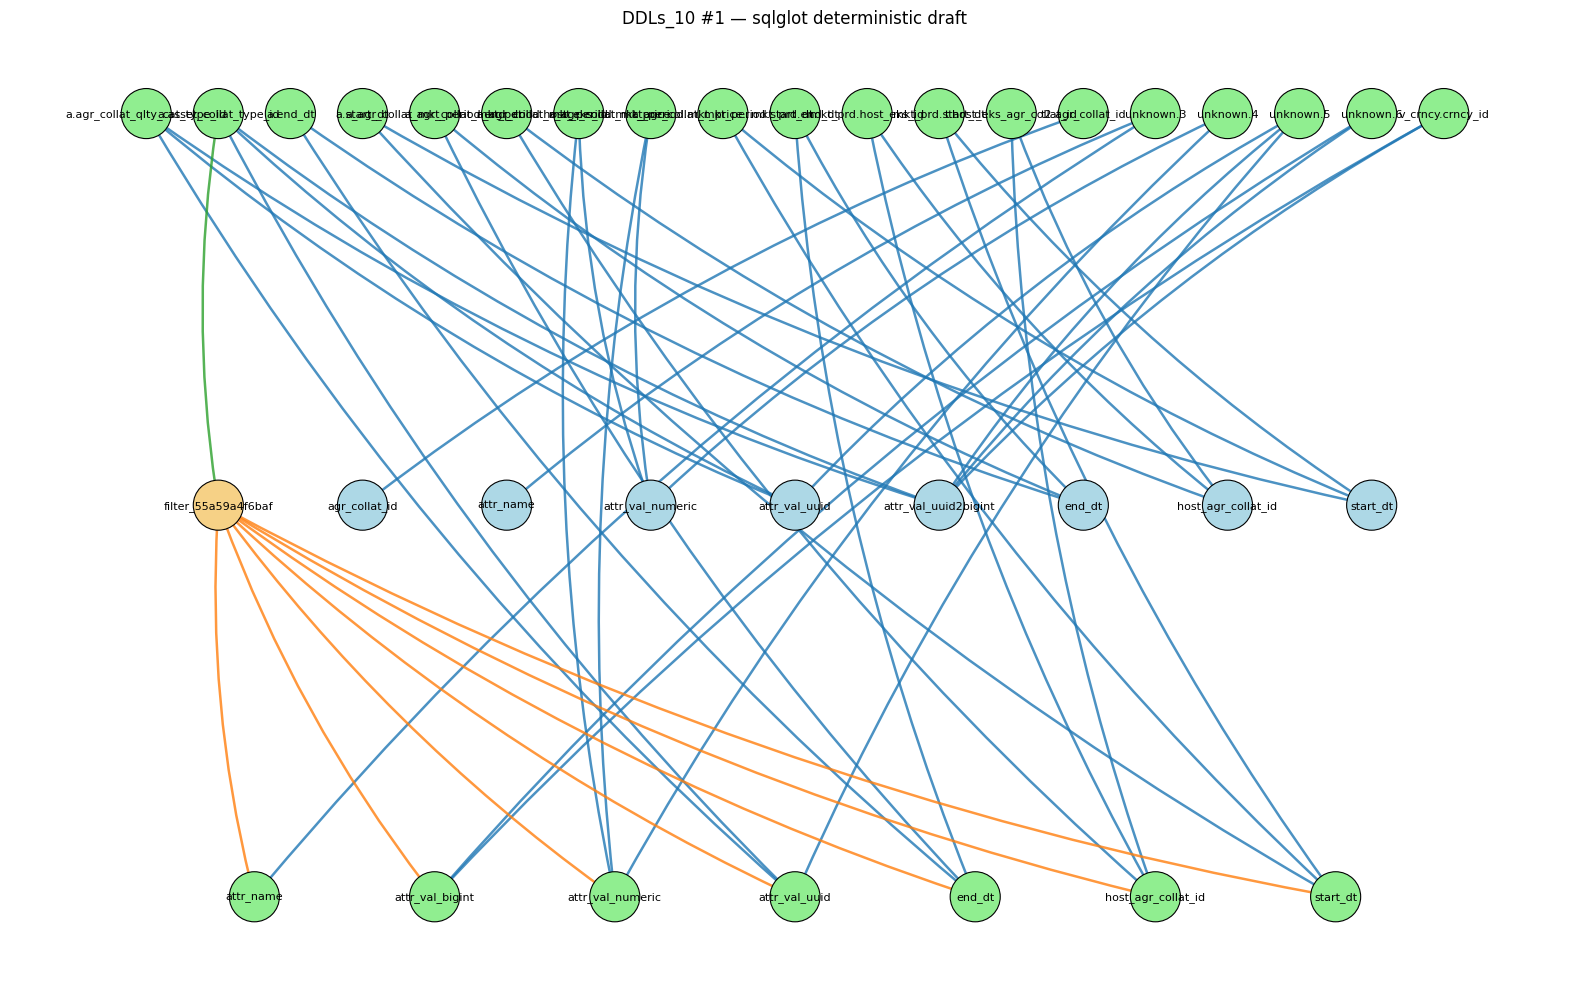

LINEAGE JSON SUMMARY
Nodes: 53
Links: 89
Node types: {'output_column': 8, 'source_column': 40, 'filter': 5}
Link types: DERIVED_FROM, FILTERED_BY, JOINS_ON, USES_COLUMN
Sample node ids: ['output.agr_collat_id', 't2.agr_collat_id', 'output.host_agr_collat_id', 'a_agr_collat_mkt_period.host_eks_id', 'mkt_prd.host_eks_id', 't.host_eks_agr_collat_id', 'output.start_dt', 'a_agr_collat_mkt_period.start_dt', 'mkt_prd.start_dt', 'a.start_dt', 'output.end_dt', 'a_agr_collat_mkt_period.end_dt', 'mkt_prd.end_dt', 'a.end_dt', 'output.attr_name', "unknown.'mkt_price_amt'", "unknown.'mkt_price_rub'", "unknown.'mkt_crncy_id'", "unknown.'agr_collat_qlty_cat_type_id'", "unknown.'asset_collat_type_id'"]
pipeline stage: llm_verified


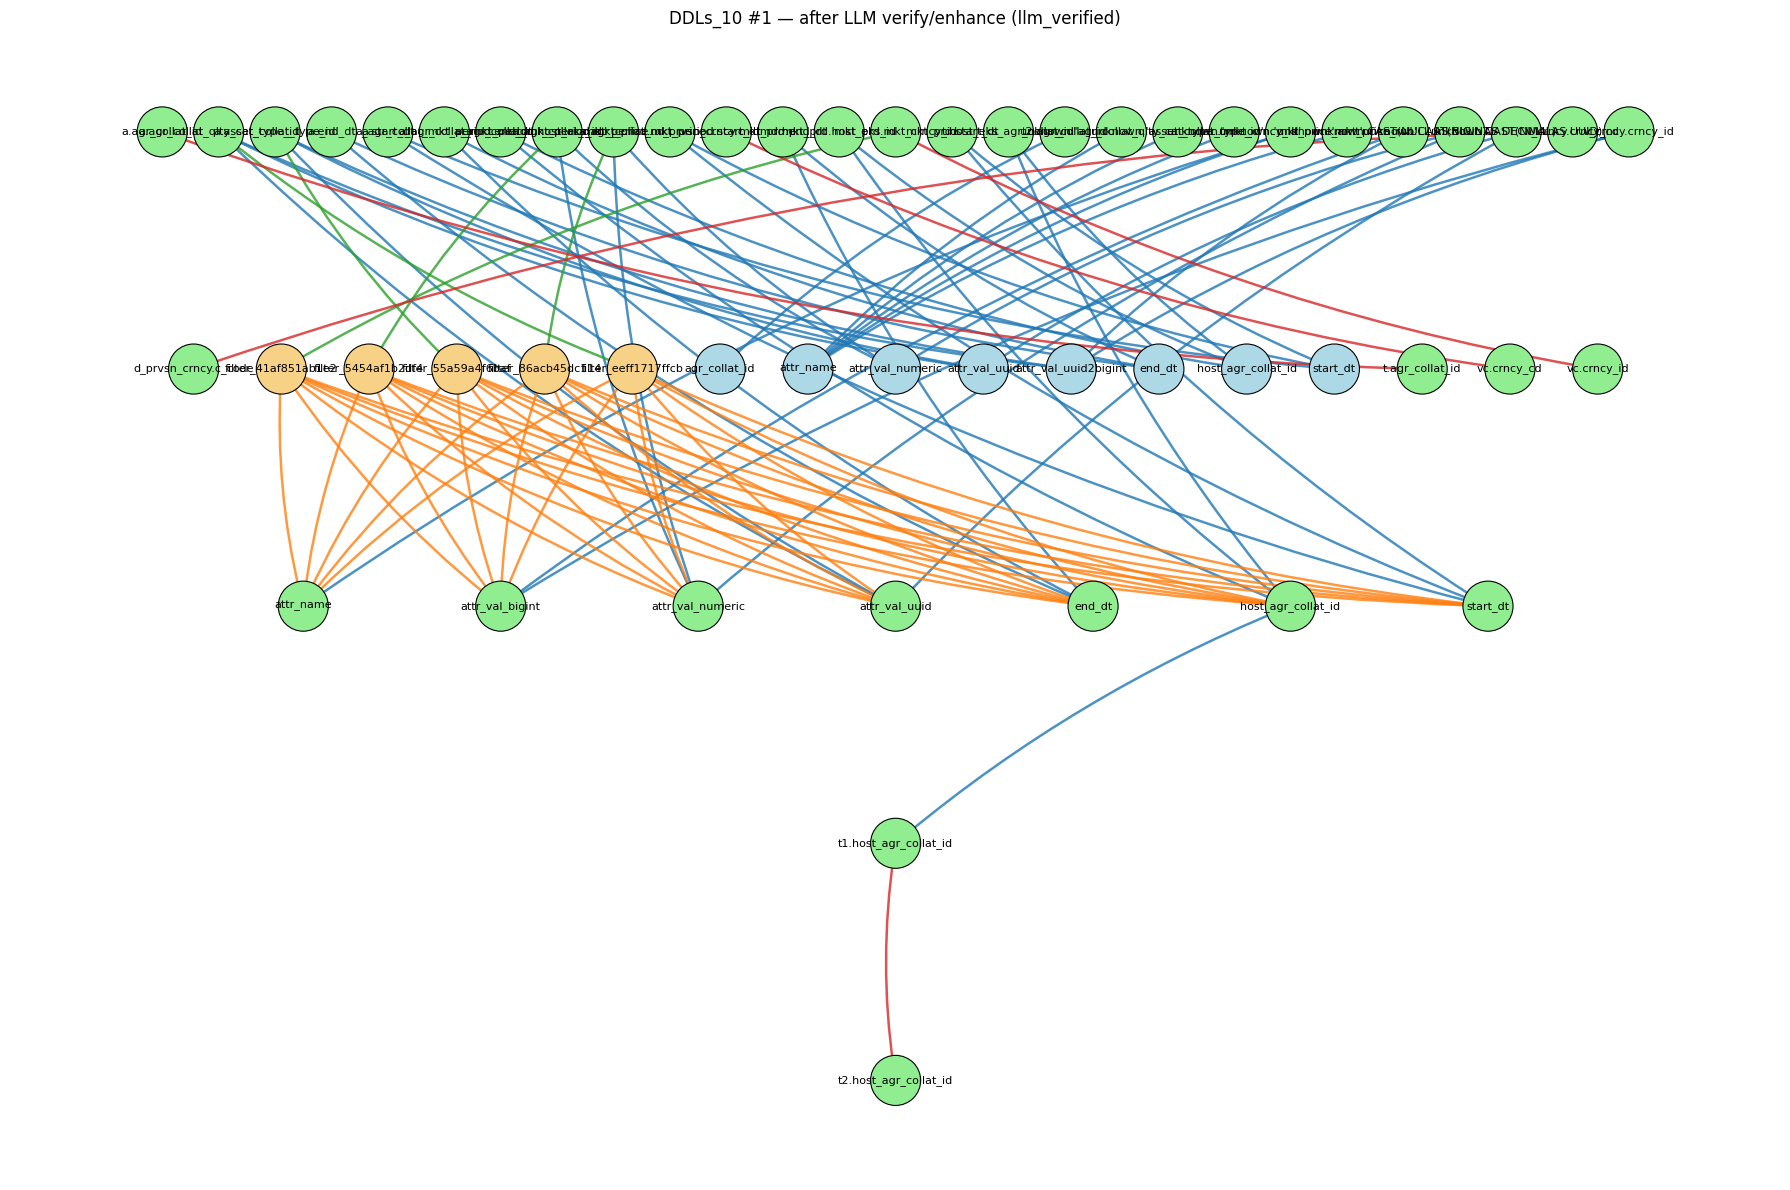

In [12]:
# 7b. Deterministic graph (sqlglot step 1 only)
from Classes import SQL2GraphBuilder

det_builder = SQL2GraphBuilder()
det_builder.build(deterministic_extraction)
SQL2GraphVisualizer.draw(
    det_builder.to_node_link(),
    title="DDLs_10 #1 — sqlglot deterministic draft",
    layout="hierarchical",
    figsize=(16, 10),
)

# 7c. Full pipeline graph (after LLM verify/enhance)
if graph_result is None:
    print("No LLM graph — run section 6 with HF_TOKEN for the verified/enhanced graph.")
else:
    full_drawer = JsonLineageDrawer.from_sql2graph_result(graph_result)
    full_drawer.print_summary()
    print("pipeline stage:", graph_result.get("pipeline_stage"))

    SQL2GraphVisualizer.draw(
        graph_result["graph"],
        title=f"DDLs_10 #1 — after LLM verify/enhance ({graph_result.get('pipeline_stage')})",
        layout="hierarchical",
        figsize=(18, 12),
    )

In [13]:
# 7c. Interactive graph (Plotly) + export HTML
if graph_result is None:
    print("Run section 6 first (requires HF_TOKEN).")
else:
    full_drawer = JsonLineageDrawer.from_sql2graph_result(graph_result)
    try:
        full_drawer.show_interactive(
            title="DDLs_10 #1 — interactive column lineage",
            height="800px",
            backend="plotly",
        )
    except Exception as exc:
        print("Plotly interactive view skipped:", exc)

    html_path = ROOT / "data" / "ddls10_first_query_lineage.html"
    full_drawer.save_html(html_path, title="DDLs_10 #1 — column lineage (sqlglot + LLM)")
    print("saved interactive HTML:", html_path)

    'data': [{'hoverinfo': 'skip',
              'legendgroup': 'edges',
       …

saved interactive HTML: /Users/nikolajabramov/PycharmProjects/llm4lineage/data/ddls10_first_query_lineage.html


## 8. Save snapshot (optional)

In [14]:
snapshot = {
    "source_file": str(DDL_FILE),
    "statement_index": 0,
    "sql_length": len(SQL),
    "dialect": DIALECT,
    "simplify": simplified,
    "column_lineage": column_lineage,
    "chunks": chunks,
    "lineage_graph": {
        "nodes": [{"id": n, **lineage_graph.nodes[n]} for n in lineage_graph.nodes],
        "links": [
            {"source": s, "target": t, **d}
            for s, t, d in lineage_graph.edges(data=True)
        ],
    },
}

out_path = ROOT / "data" / "ddls10_first_query_snapshot.json"
out_path.write_text(json.dumps(snapshot, indent=2), encoding="utf-8")
print("saved:", out_path)

saved: /Users/nikolajabramov/PycharmProjects/llm4lineage/data/ddls10_first_query_snapshot.json
